In [1]:
!pip install statsforecast

import warnings
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import re

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

from statsforecast import StatsForecast
from statsforecast.models import WindowAverage, SeasonalNaive 
from statsforecast.models import AutoARIMA

from statsmodels.tsa.seasonal import seasonal_decompose

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00


# Data Cleaning and Processing

In [2]:
bakery = pd.read_csv('/kaggle/input/french-bakery-daily-sales/Bakery sales.csv',
                     parse_dates=['date'])

We will be working with a subset of this data. Specifically, the rows that pertain to baguette sales and to croissant sales. The first reason for this is that these particular goods are popular and therefore sold regularly, whereas other bakery items in this dataset are not. The other reason is because training time series models takes a lot of time, so we don't want to have to train models for the sales of every bakery item in the dataset.

In [3]:
bakery.head()

,Unnamed: 0,date,time,ticket_number,article,Quantity,unit_price
0,0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,5,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,8,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [4]:
bakery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234005 entries, 0 to 234004
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Unnamed: 0     234005 non-null  int64         
 1   date           234005 non-null  datetime64[ns]
 2   time           234005 non-null  object        
 3   ticket_number  234005 non-null  float64       
 4   article        234005 non-null  object        
 5   Quantity       234005 non-null  float64       
 6   unit_price     234005 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 12.5+ MB


In [5]:
bakery['unit_price'] = bakery['unit_price'].astype(str)
bakery['unit_price'] = bakery['unit_price'].str.replace(',','.',regex=False)
bakery['unit_price'] = bakery['unit_price'].str.replace(r'[^\d.]','',regex=True)

bakery['unit_price'] = pd.to_numeric(bakery['unit_price'], errors='coerce')

bakery = bakery.rename(columns={'unit_price': 'unit_price_euro'})

In [6]:
# Seeing if baguette prices change in the data

bakery[bakery['article'] =='BAGUETTE']['unit_price_euro'].unique()

array([0.9 , 0.95, 1.  ])

In [7]:
# Seeing if croissant prices change in the data

bakery[bakery['article'] == 'CROISSANT']['unit_price_euro'].unique()

array([1.1 , 1.15, 1.2 ])

In [8]:
# Combining the date and the hour of day to 1 variable

bakery['datetime'] = (bakery['date'].dt.strftime('%Y-%m-%d') +
                      ' ' + bakery['time'].astype(str))

bakery['datetime'] = pd.to_datetime(bakery['datetime'])


# Dropping unnecessary variables from the table

bakery = bakery.drop(['date','time','Unnamed: 0','ticket_number'], axis = 1)

In [9]:
bakery.head()

,article,Quantity,unit_price_euro,datetime
0,BAGUETTE,1.0,0.90,2021-01-02 08:38:00
1,PAIN AU CHOCOLAT,3.0,1.20,2021-01-02 08:38:00
2,PAIN AU CHOCOLAT,2.0,1.20,2021-01-02 09:14:00
3,PAIN,1.0,1.15,2021-01-02 09:14:00
4,TRADITIONAL BAGUETTE,5.0,1.20,2021-01-02 09:25:00


In [10]:
bakery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234005 entries, 0 to 234004
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   article          234005 non-null  object        
 1   Quantity         234005 non-null  float64       
 2   unit_price_euro  234005 non-null  float64       
 3   datetime         234005 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 7.1+ MB


In [11]:
min_date = bakery['datetime'].min()
max_date = bakery['datetime'].max()

message = f"Earliest Date: {min_date}, Latest Date: {max_date}."
print(message)

Earliest Date: 2021-01-02 08:38:00, Latest Date: 2022-09-30 18:56:00.


In [12]:
# Getting just 1 value for each day recorded for the numeric variables

bakery['date_only'] = bakery['datetime'].dt.date

aggregation_rules = {
    'Quantity': 'sum', 
    'unit_price_euro': 'mean'}

df_daily_summary = (bakery.groupby(['article', 'date_only']).agg(aggregation_rules)
                    .reset_index())

df_daily_summary['date_only'] = pd.to_datetime(df_daily_summary['date_only'])

In [13]:
df_daily_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29202 entries, 0 to 29201
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   article          29202 non-null  object        
 1   date_only        29202 non-null  datetime64[ns]
 2   Quantity         29202 non-null  float64       
 3   unit_price_euro  29202 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 912.7+ KB


In [14]:
# We want only bakery items with 500 or more entries
df_full = (df_daily_summary.groupby('article').filter(lambda x: len(x) >= 500))

# We only want datetime and Quanitity sold for non exog TS
df_simple = df_full.drop(['unit_price_euro'], axis = 1)

# These df names are needed for plot_series to work
df_simple = df_simple.rename(columns={'date_only': 'ds','article': 'unique_id',
                                      'Quantity': 'y'})

In [15]:
df_simple.head(7)

,unique_id,ds,y
50,BAGUETTE,2021-01-02,46.0
51,BAGUETTE,2021-01-03,35.0
52,BAGUETTE,2021-01-04,30.0
53,BAGUETTE,2021-01-05,29.0
54,BAGUETTE,2021-01-07,28.0
55,BAGUETTE,2021-01-08,17.0
56,BAGUETTE,2021-01-09,25.0


In [16]:
df_simple.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16052 entries, 50 to 28212
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  16052 non-null  object        
 1   ds         16052 non-null  datetime64[ns]
 2   y          16052 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 501.6+ KB


# Visualizing Time Series

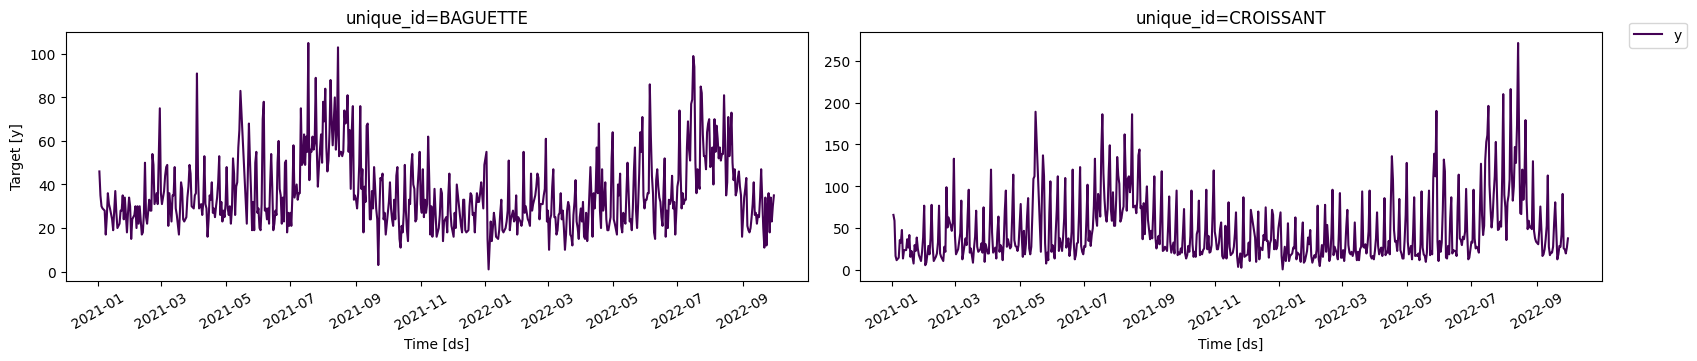

In [17]:
plot_series(df=df_simple, ids=['BAGUETTE','CROISSANT'],
            palette = 'viridis')

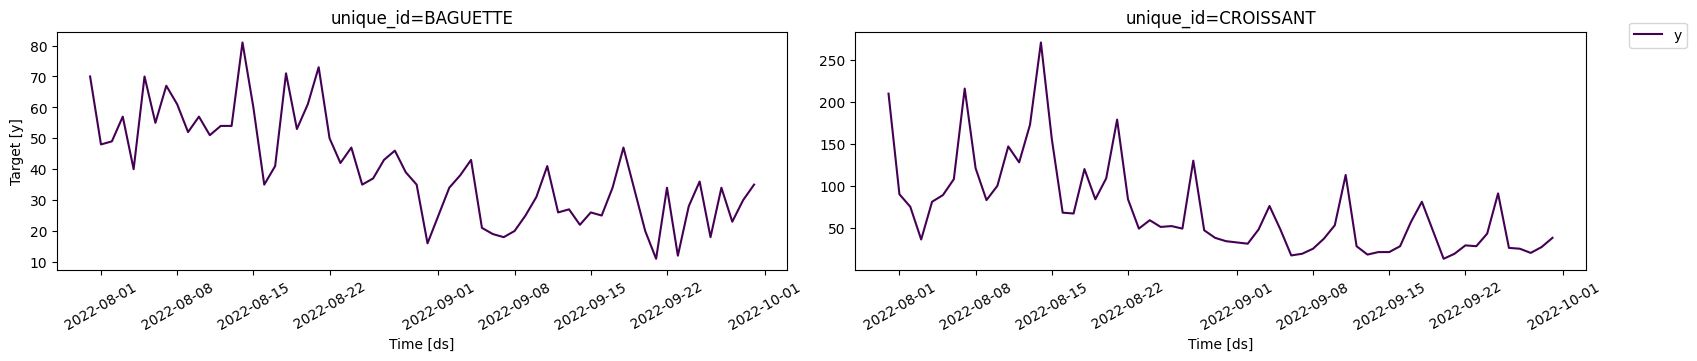

In [18]:
# Only plotting last 56 timestamps, allowing zoom in

plot_series(df=df_simple, ids=['BAGUETTE','CROISSANT'],
            max_insample_length = 60, palette = 'viridis')

In [19]:
Bague_data = df_simple[df_simple['unique_id'] == 'BAGUETTE'].copy()

Bague_data['month_num'] = Bague_data['ds'].dt.month
Bague_data['month_name'] = Bague_data['ds'].dt.month_name()

Bague_data['day_wk_num'] = Bague_data['ds'].dt.dayofweek
Bague_data['day_wk_name'] = Bague_data['ds'].dt.day_name()

##########################################################################

mean_by_month = Bague_data.groupby(['month_num',
                                    'month_name'])['y'].mean().reset_index()

mean_by_month = mean_by_month.sort_values('month_num')
mean_by_month.drop(columns=['month_num'], inplace=True)
mean_by_month.rename(columns={'y': 'mean_units_sold'}, inplace=True)
mean_by_month = mean_by_month[['month_name', 'mean_units_sold']]

print("Average Number of Baguettes Sold in a Day by Month (Across All Years):\n")
print(mean_by_month.to_markdown(index=False, floatfmt=".2f"))

##########################################################################

mean_by_day_of_week = Bague_data.groupby(['day_wk_num',
                                          'day_wk_name'])['y'].mean().reset_index()

mean_by_day_of_week = mean_by_day_of_week.sort_values('day_wk_num')
mean_by_day_of_week.drop(columns=['day_wk_num'], inplace=True)
mean_by_day_of_week.rename(columns={'y': 'mean_units_sold'}, inplace=True)
mean_by_day_of_week = mean_by_day_of_week[['day_wk_name', 'mean_units_sold']]

print("\n\nMean Number of Baguettes Sold by Day of Week:\n")
print(mean_by_day_of_week.to_markdown(index=False, floatfmt=".2f"))

Average Number of Baguettes Sold in a Day by Month (Across All Years):

| month_name   |   mean_units_sold |
|:-------------|------------------:|
| January      |             26.12 |
| February     |             32.42 |
| March        |             29.07 |
| April        |             32.58 |
| May          |             38.23 |
| June         |             34.58 |
| July         |             53.82 |
| August       |             57.19 |
| September    |             32.09 |
| October      |             31.71 |
| November     |             29.43 |
| December     |             29.04 |


Mean Number of Baguettes Sold by Day of Week:

| day_wk_name   |   mean_units_sold |
|:--------------|------------------:|
| Monday        |             34.35 |
| Tuesday       |             31.04 |
| Wednesday     |             30.08 |
| Thursday      |             31.04 |
| Friday        |             32.87 |
| Saturday      |             41.79 |
| Sunday        |             53.70 |


In [20]:
Croi_data = df_simple[df_simple['unique_id'] == 'CROISSANT'].copy()

Croi_data['month_num'] = Croi_data['ds'].dt.month
Croi_data['month_name'] = Croi_data['ds'].dt.month_name()

Croi_data['day_wk_num'] = Croi_data['ds'].dt.dayofweek
Croi_data['day_wk_name'] = Croi_data['ds'].dt.day_name()

##########################################################################

mean_by_month = Croi_data.groupby(['month_num',
                                   'month_name'])['y'].mean().reset_index()

mean_by_month = mean_by_month.sort_values('month_num')
mean_by_month.drop(columns=['month_num'], inplace=True)
mean_by_month.rename(columns={'y': 'mean_units_sold'}, inplace=True)
mean_by_month = mean_by_month[['month_name', 'mean_units_sold']]

print("Average Number of Croissants Sold in a Day by Month (Across All Years):\n")
print(mean_by_month.to_markdown(index=False, floatfmt=".2f"))

##########################################################################

mean_by_day_of_week = Croi_data.groupby(['day_wk_num',
                                         'day_wk_name'])['y'].mean().reset_index()

mean_by_day_of_week = mean_by_day_of_week.sort_values('day_wk_num')
mean_by_day_of_week.drop(columns=['day_wk_num'], inplace=True)
mean_by_day_of_week.rename(columns={'y': 'mean_units_sold'}, inplace=True)
mean_by_day_of_week = mean_by_day_of_week[['day_wk_name', 'mean_units_sold']]

print("\n\nMean Number of Croissants Sold by Day of Week:\n")
print(mean_by_day_of_week.to_markdown(index=False, floatfmt=".2f"))

Average Number of Croissants Sold in a Day by Month (Across All Years):

| month_name   |   mean_units_sold |
|:-------------|------------------:|
| January      |             28.63 |
| February     |             36.58 |
| March        |             33.18 |
| April        |             41.41 |
| May          |             54.09 |
| June         |             44.58 |
| July         |             80.19 |
| August       |             95.50 |
| September    |             41.26 |
| October      |             39.26 |
| November     |             31.93 |
| December     |             36.96 |


Mean Number of Croissants Sold by Day of Week:

| day_wk_name   |   mean_units_sold |
|:--------------|------------------:|
| Monday        |             40.09 |
| Tuesday       |             30.38 |
| Wednesday     |             33.89 |
| Thursday      |             35.06 |
| Friday        |             37.26 |
| Saturday      |             59.62 |
| Sunday        |            104.15 |


In [21]:
Baguette_data = df_simple[df_simple['unique_id'] == 'BAGUETTE'].copy()
baguette_ts = Baguette_data.set_index('ds')['y']

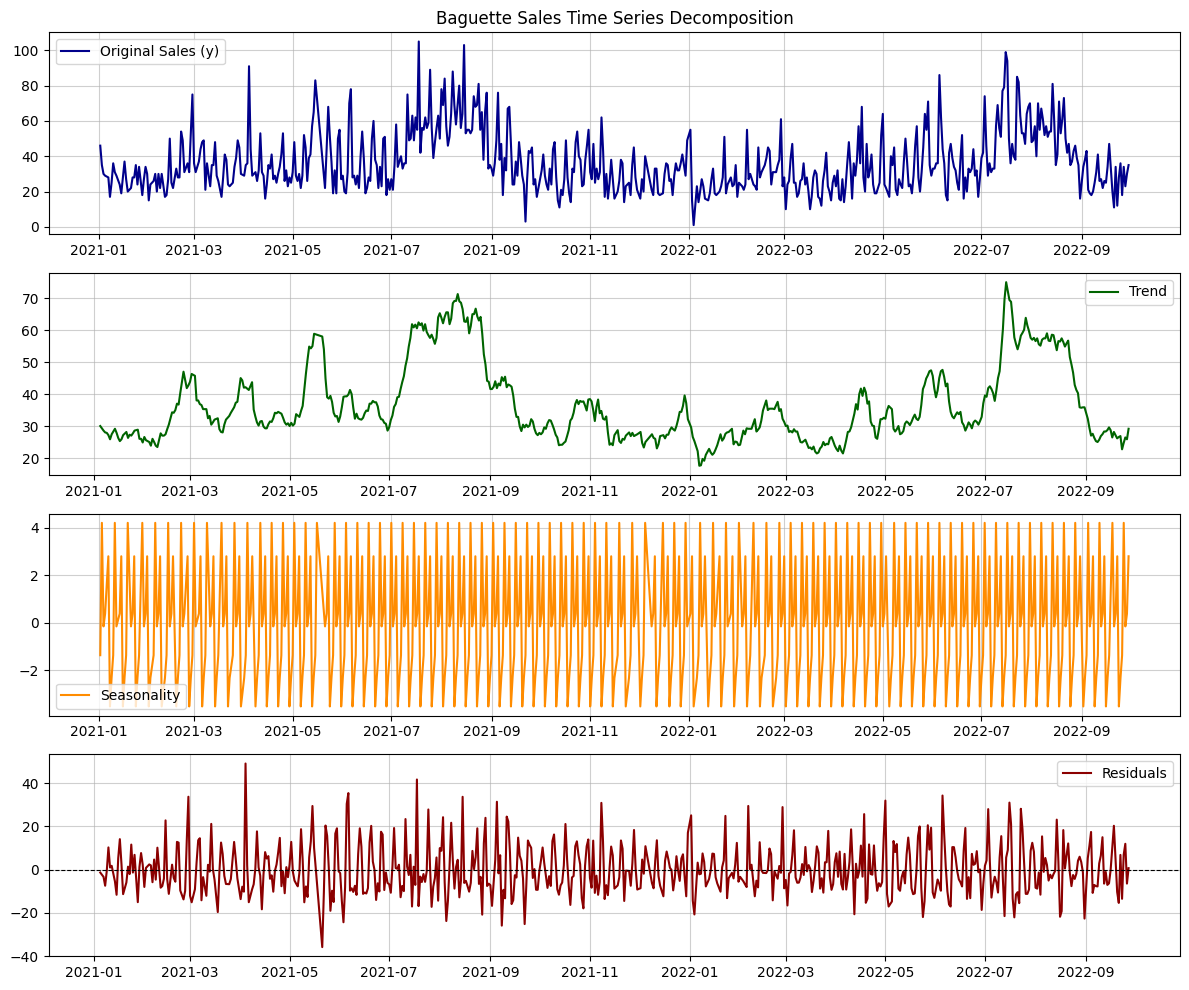


--- Decomposition Summary ---
Data Points used: 600
Decomposition Model: Additive (y = Trend + Seasonality + Residuals)
Seasonality Period: 7 (Assumes weekly seasonality based on daily data)
Check the generated plot to see the Trend, Seasonality, and Residual components.


In [22]:
decomposition = seasonal_decompose(baguette_ts, model='additive', period=7)

# --- Plot the Decomposition ---
plt.figure(figsize=(12, 10))

# The original time series
plt.subplot(411)
plt.plot(baguette_ts, label='Original Sales (y)', color='darkblue')
plt.title('Baguette Sales Time Series Decomposition')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Trend Component (the long-term movement)
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='darkgreen')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Seasonal Component (the repeating short-term pattern, weekly)
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='darkorange')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Residuals (the unexplained, irregular fluctuations)
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='darkred')
plt.legend(loc='best')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Add zero line for clarity
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()


print("\n--- Decomposition Summary ---")
print(f"Data Points used: {len(baguette_ts)}")
print("Decomposition Model: Additive (y = Trend + Seasonality + Residuals)")
print("Seasonality Period: 7 (Assumes weekly seasonality based on daily data)")
print("Check the generated plot to see the Trend, Seasonality, and Residual components.")

In [23]:
croissant_data = df_simple[df_simple['unique_id'] == 'CROISSANT'].copy()
croissant_ts = croissant_data.set_index('ds')['y']

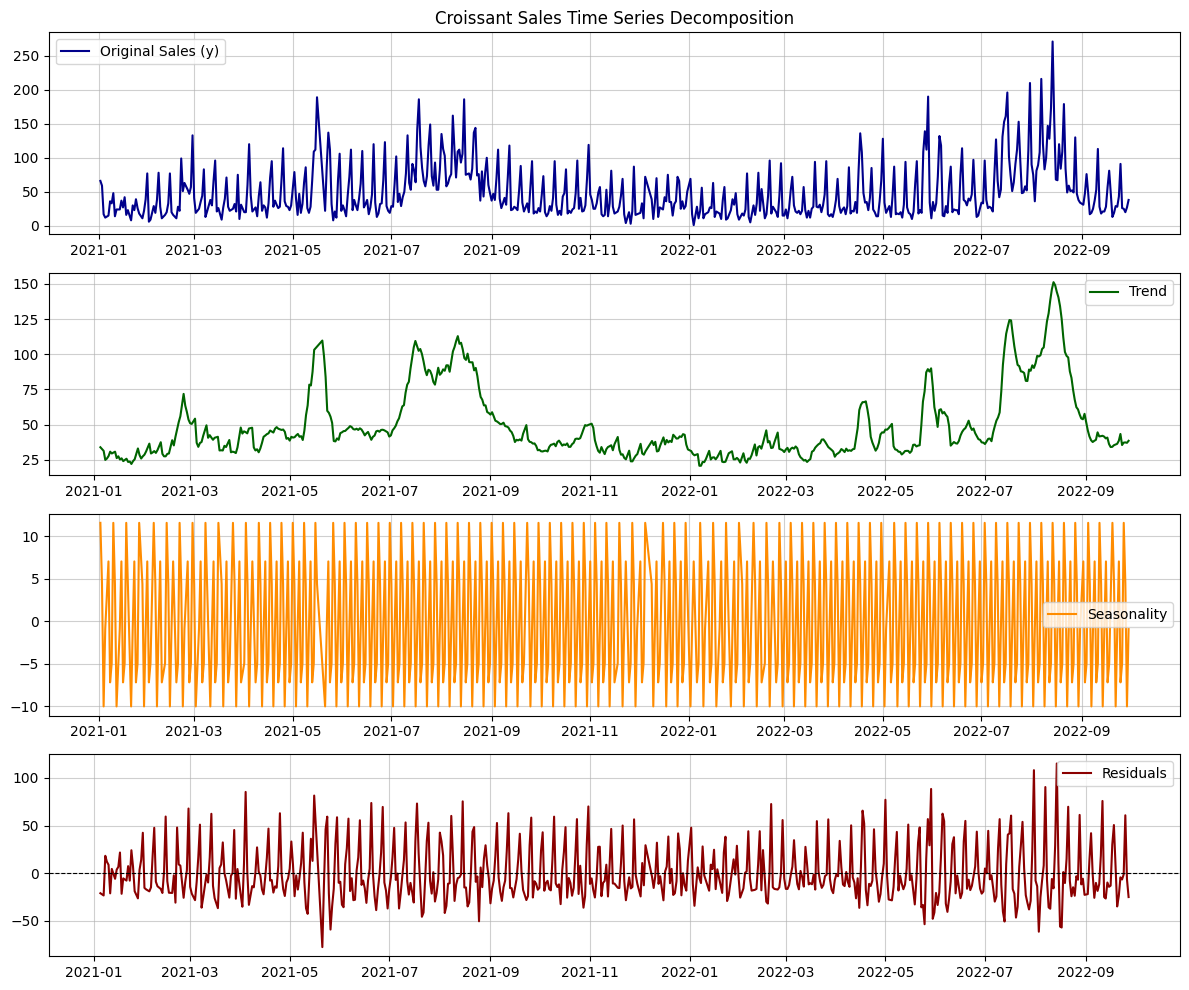


--- Decomposition Summary ---
Data Points used: 599
Decomposition Model: Additive (y = Trend + Seasonality + Residuals)
Seasonality Period: 7 (Assumes weekly seasonality based on daily data)
Check the generated plot to see the Trend, Seasonality, and Residual components.


In [24]:
decomposition = seasonal_decompose(croissant_ts, model='additive', period=7)

# --- Plot the Decomposition ---
plt.figure(figsize=(12, 10))

# The original time series
plt.subplot(411)
plt.plot(croissant_ts, label='Original Sales (y)', color='darkblue')
plt.title('Croissant Sales Time Series Decomposition')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Trend Component (the long-term movement)
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='darkgreen')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Seasonal Component (the repeating short-term pattern, weekly)
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='darkorange')
plt.legend(loc='best')
plt.grid(True, alpha=0.6)

# Residuals (the unexplained, irregular fluctuations)
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='darkred')
plt.legend(loc='best')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Add zero line for clarity
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()


print("\n--- Decomposition Summary ---")
print(f"Data Points used: {len(croissant_ts)}")
print("Decomposition Model: Additive (y = Trend + Seasonality + Residuals)")
print("Seasonality Period: 7 (Assumes weekly seasonality based on daily data)")
print("Check the generated plot to see the Trend, Seasonality, and Residual components.")

Both baguette and croissant sales show a clear increase, on average, during July and August. This suggests a positive correlation with the summer season, likely due to increased tourism. Both products experience a noticeable increase in sales on Saturdays and a significant surge on Sundays (especially croissant sales). When examining the seasonal components of the decomposed (period=7) time series plots for both baguette sales and croissant sales, it seems like there is a consistent and cyclical weekly pattern that is repeating. Based on the average day of week sales tables for both products, the repeating spikes in the seasonal component plots for both baguette sales and croissant sales would be the higher than normal sales that repeat every Sunday. Based on this it makes sense to try a seasonal (7 day) ARIMA model for forecasting.  

# Model Building (No Exogenous Variables)

In [25]:
# Making test data that is last 30 days for each class

test = df_simple.groupby('unique_id').tail(30)
train = df_simple.drop(test.index).reset_index(drop=True)

# Getting a subset of the classes so we don't model them all

subset_unique_ids = ['BAGUETTE','CROISSANT']

subset_train = train[train['unique_id'].isin(subset_unique_ids)].copy() 
subset_test = test[test['unique_id'].isin(subset_unique_ids)].copy() 

In [26]:
# Making models to predict horizon of next 30 days

horizon = 30

my_models = [

    WindowAverage(window_size=30),
    SeasonalNaive(season_length=30),
    AutoARIMA(seasonal = False, alias = 'ARIMA'),
    AutoARIMA(season_length = 7, alias = 'SARIMA(7)')
    
]

sf = StatsForecast(models = my_models, freq = 'D')
sf.fit(subset_train)

arima_preds = sf.predict(h=horizon)

arima_preds.head()

,unique_id,ds,WindowAverage,SeasonalNaive,ARIMA,SARIMA(7)
0,BAGUETTE,2022-08-30,53.3,70.0,38.425000,36.388588
1,BAGUETTE,2022-08-31,53.3,48.0,37.032800,40.112918
2,BAGUETTE,2022-09-01,53.3,49.0,38.571535,40.299623
3,BAGUETTE,2022-09-02,53.3,57.0,46.579772,41.604364
4,BAGUETTE,2022-09-03,53.3,40.0,49.066781,45.467929


In [27]:
# We need the actual y value and model predictions in one table

eval_df = pd.merge(subset_test,arima_preds,'left',['ds','unique_id'])
eval_df.head()

,unique_id,ds,y,WindowAverage,SeasonalNaive,ARIMA,SARIMA(7)
0,BAGUETTE,2022-08-30,35.0,53.3,70.0,38.425000,36.388588
1,BAGUETTE,2022-08-31,16.0,53.3,48.0,37.032800,40.112918
2,BAGUETTE,2022-09-02,34.0,53.3,57.0,46.579772,41.604364
3,BAGUETTE,2022-09-03,38.0,53.3,40.0,49.066781,45.467929
4,BAGUETTE,2022-09-04,43.0,53.3,70.0,51.254922,52.342896


In [28]:
# Using the actual y and the predictions, MAE is calculated

evaluation = evaluate(eval_df, metrics = [mae])

evaluation.head()

,unique_id,metric,WindowAverage,SeasonalNaive,ARIMA,SARIMA(7)
0,BAGUETTE,mae,26.014286,25.892857,16.478481,12.737967
1,CROISSANT,mae,69.288095,72.821429,15.288966,37.182680


In [29]:
df_melted = pd.melt(evaluation, id_vars=['unique_id'], 
                    value_vars=['WindowAverage','SeasonalNaive',
                                'ARIMA','SARIMA(7)'],
                    var_name='Model',
                    value_name='MAE')

df_melted.head(10)

,unique_id,Model,MAE
0,BAGUETTE,WindowAverage,26.014286
1,CROISSANT,WindowAverage,69.288095
2,BAGUETTE,SeasonalNaive,25.892857
3,CROISSANT,SeasonalNaive,72.821429
4,BAGUETTE,ARIMA,16.478481
5,CROISSANT,ARIMA,15.288966
6,BAGUETTE,SARIMA(7),12.737967
7,CROISSANT,SARIMA(7),37.182680


# Visualizing Non Exogenous Models

In [30]:
# Making dataframes to use for Model MAE barplots

Bag_MAE = df_melted[df_melted['unique_id'] == 'BAGUETTE']
Cro_MAE = df_melted[df_melted['unique_id'] == 'CROISSANT']

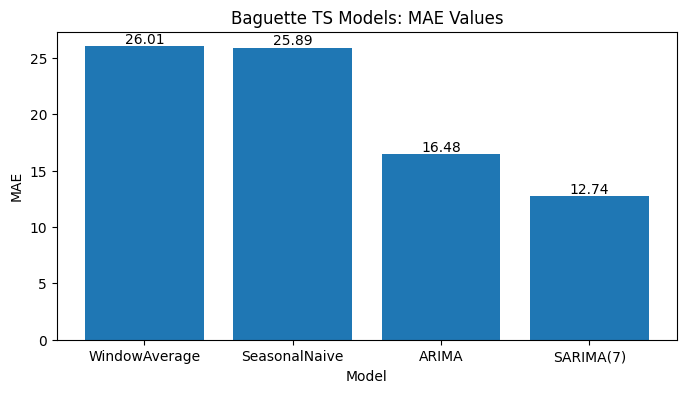

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Bag_MAE['Model'], Bag_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Baguette TS Models: MAE Values')

plt.show()

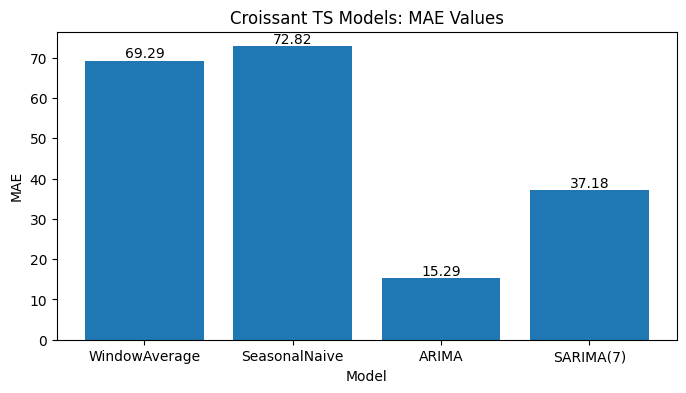

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Cro_MAE['Model'], Cro_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Croissant TS Models: MAE Values')

plt.show()

## All Models

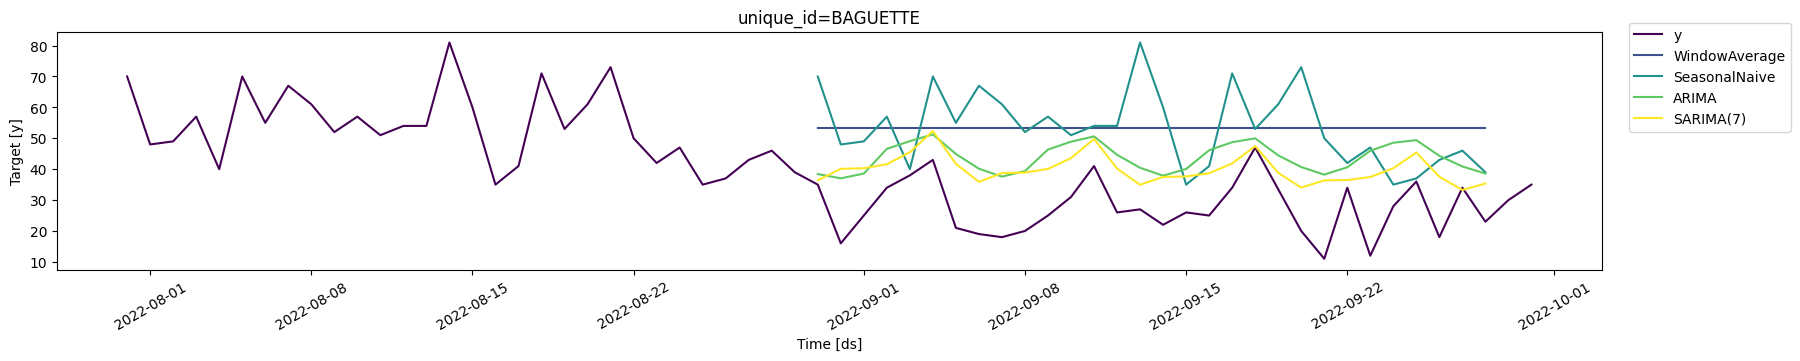

In [33]:
plot_series(
    df=df_simple,
    forecasts_df = arima_preds,
    ids = ['BAGUETTE'],
    max_insample_length = 60,
    palette = 'viridis'
)

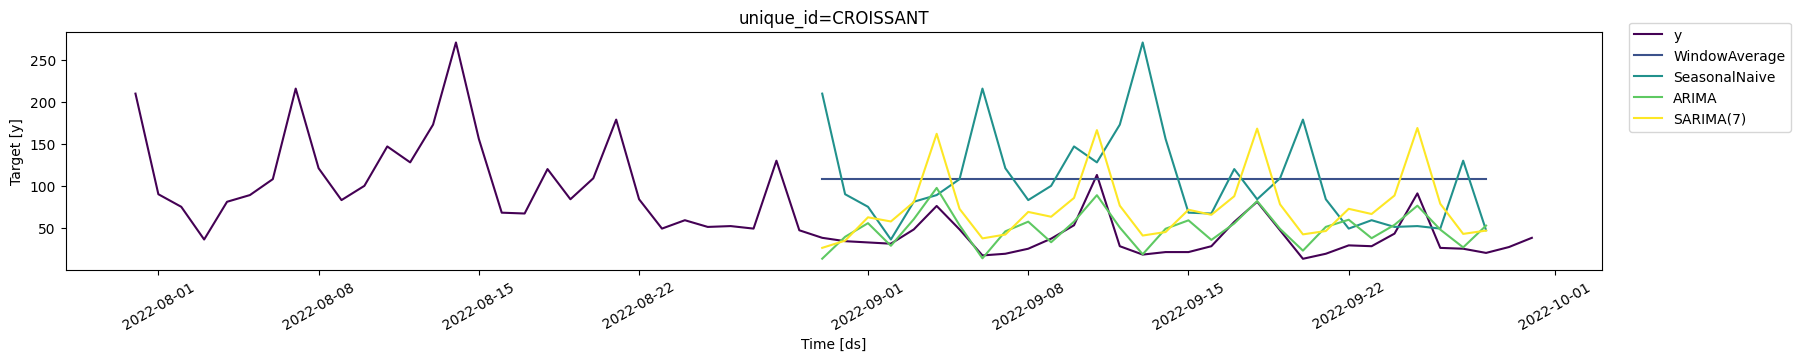

In [34]:
plot_series(
    df=df_simple,
    forecasts_df = arima_preds,
    ids = ['CROISSANT'],
    max_insample_length = 60,
    palette = 'viridis'
)

## Best Models

In [35]:
baguette_preds_best = arima_preds.drop(['WindowAverage','SeasonalNaive'],
                                       axis = 1)

croissant_preds_best = arima_preds.drop(['WindowAverage','SeasonalNaive'],
                                        axis = 1)

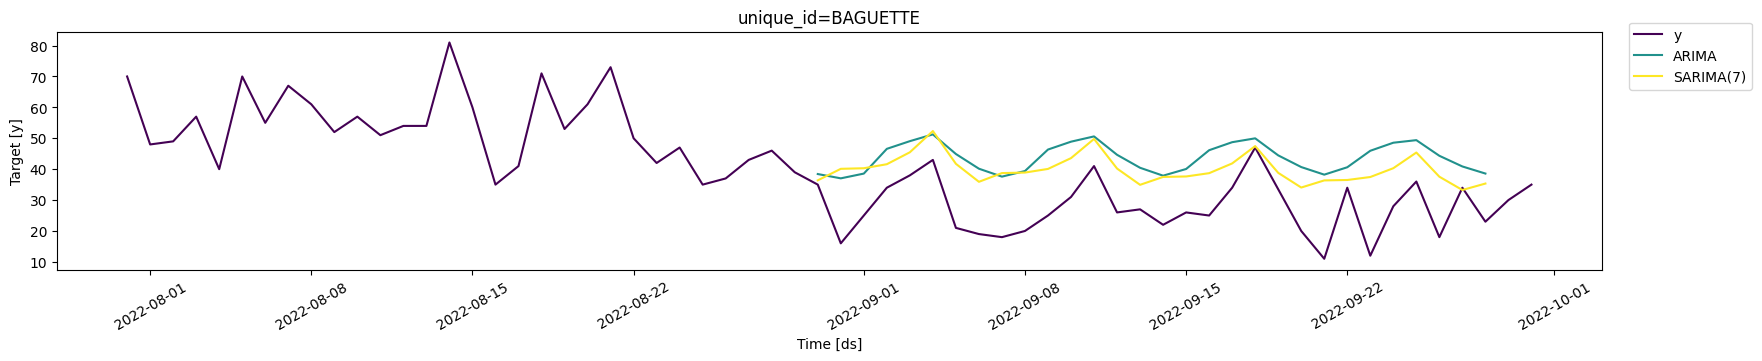

In [36]:
plot_series(
    df=df_simple,
    forecasts_df = baguette_preds_best,
    ids = ['BAGUETTE'],
    max_insample_length = 60,
    palette = 'viridis'
)

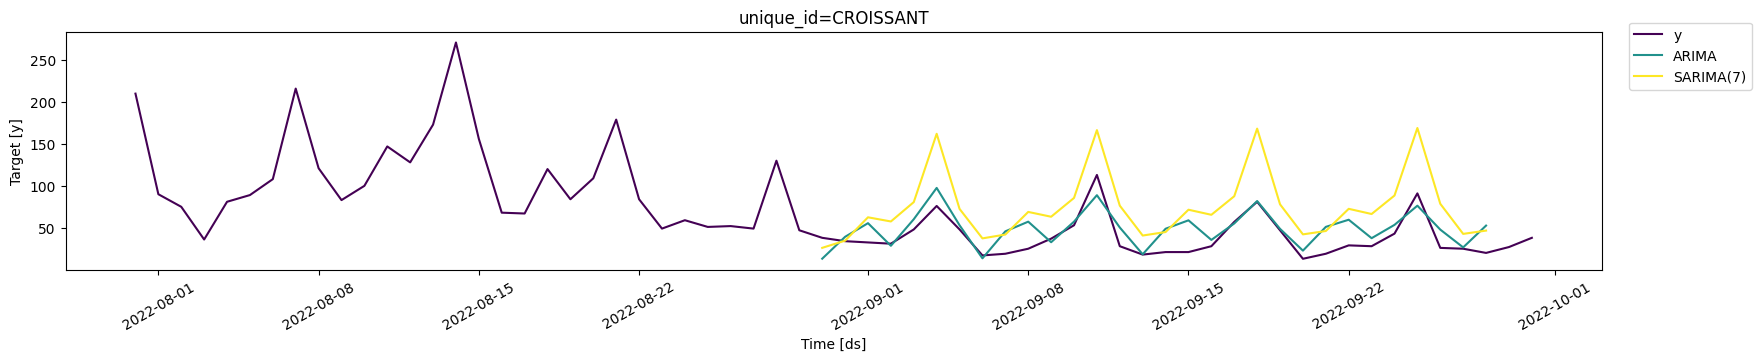

In [37]:
plot_series(
    df=df_simple,
    forecasts_df = croissant_preds_best,
    ids = ['CROISSANT'],
    max_insample_length = 60,
    palette = 'viridis'
)

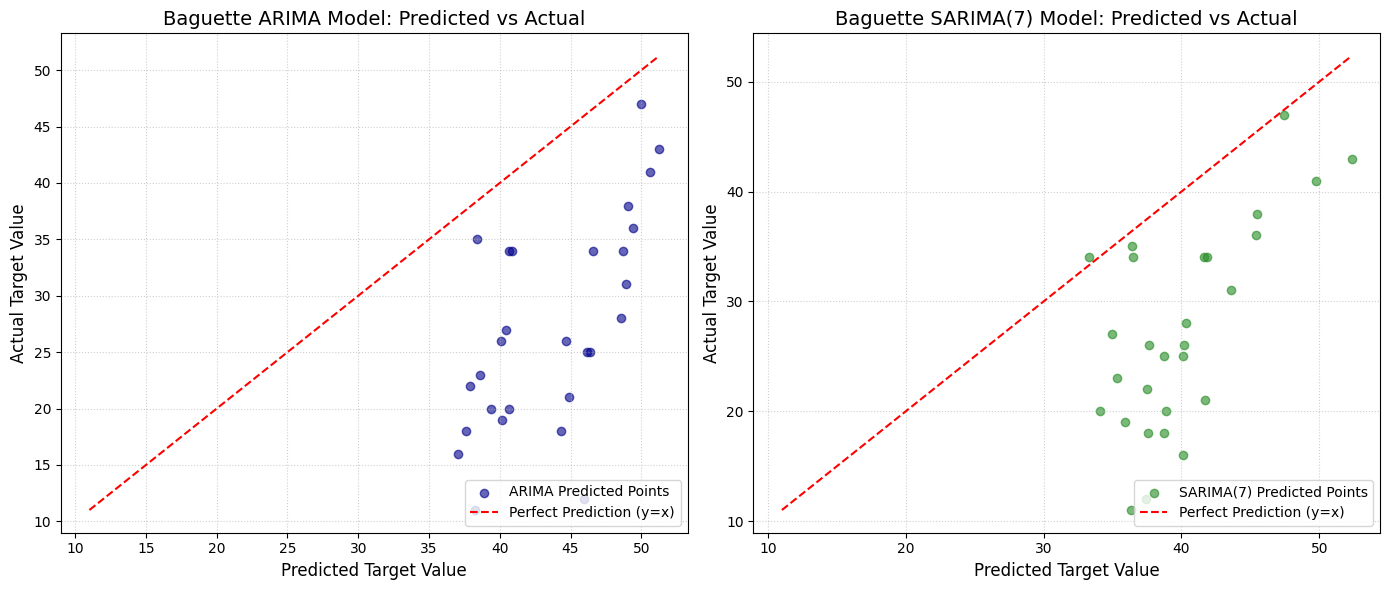

In [38]:
# Get data ready for plotting the two graphs

Bag_Actual = eval_df[eval_df['unique_id'] == 'BAGUETTE']['y']

Bag_pred_arima = eval_df[eval_df['unique_id'] == 'BAGUETTE']['ARIMA']
Bag_pred_sarima7 = eval_df[eval_df['unique_id'] == 'BAGUETTE']['SARIMA(7)']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Bag_pred_arima, Bag_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Bag_pred_arima.min(), Bag_Actual.min())
max_val1 = max(Bag_pred_arima.max(), Bag_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Baguette ARIMA Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Bag_pred_sarima7, Bag_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Bag_pred_sarima7.min(), Bag_Actual.min())
max_val2 = max(Bag_pred_sarima7.max(), Bag_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Baguette SARIMA(7) Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

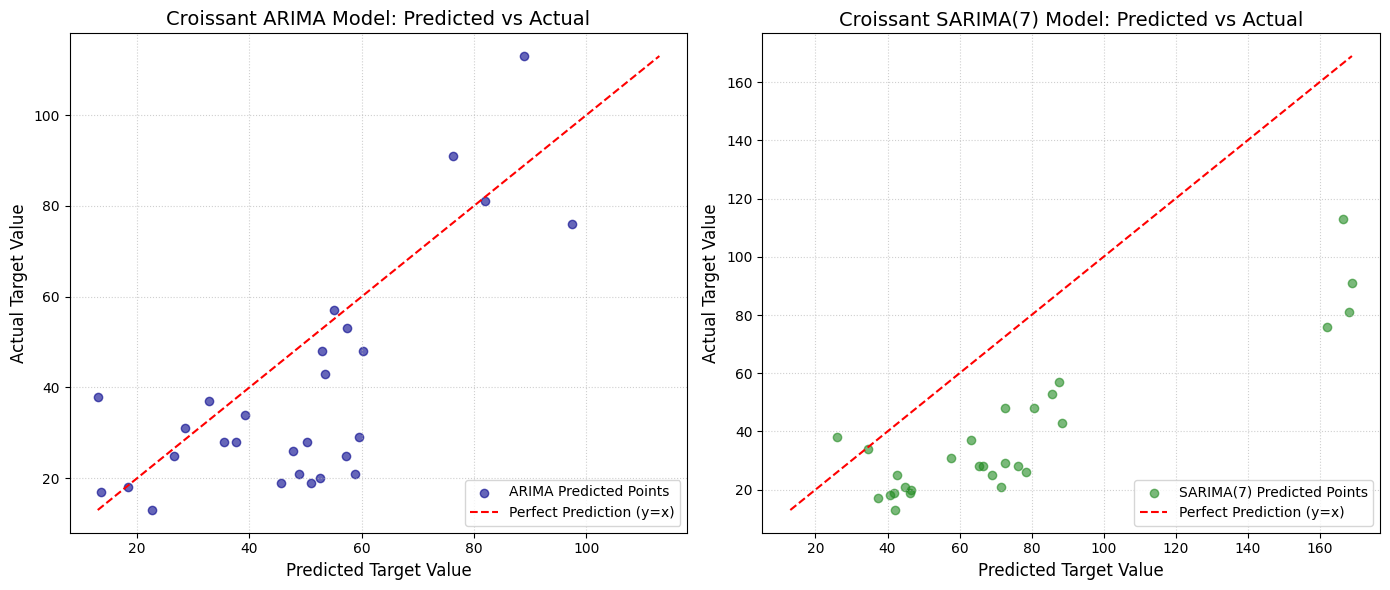

In [39]:
# Get data ready for plotting the two graphs

Cro_Actual = eval_df[eval_df['unique_id'] == 'CROISSANT']['y']

Cro_pred_arima = eval_df[eval_df['unique_id'] == 'CROISSANT']['ARIMA']
Cro_pred_sarima7 = eval_df[eval_df['unique_id'] == 'CROISSANT']['SARIMA(7)']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Cro_pred_arima, Cro_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Cro_pred_arima.min(), Cro_Actual.min())
max_val1 = max(Cro_pred_arima.max(), Cro_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Croissant ARIMA Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Cro_pred_sarima7, Cro_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Cro_pred_sarima7.min(), Cro_Actual.min())
max_val2 = max(Cro_pred_sarima7.max(), Cro_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Croissant SARIMA(7) Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

The ARIMA and SARIMA(7) models significantly outperformed the WindowAverage and Seasonal Naive baseline models in forecasting both baguette and croissant sales. SARIMA(7) yielded the best predictions for Baguette sales with a Mean Absolute Error (MAE) of 12.74. The ARIMA model was the superior option for Croissant sales predictions, with a Mean Absolute Error (MAE) of 15.29. 

# Model Building (Exogenous Variables)

In [40]:
# Making additional exogenous variables (+ unit_price_euro) for dataframe
df_exog = df_full.copy()


# Rename the columns so they work with the StatsForecast library 
df_exog = df_exog.rename(columns={'date_only': 'ds','article': 'unique_id',
                                      'Quantity': 'y'})

# Extract extra exogenous variables for prediction (Month, Day)
df_exog['Month'] = df_exog['ds'].dt.strftime('%B')
df_exog['DayOfWeek'] = df_exog['ds'].dt.strftime('%A')


# Classify all days that are not Saturday or Sunday as 'Weekday'
df_exog['DayOfWeek'] = np.where(
    df_exog['DayOfWeek'].isin(['Saturday', 'Sunday']),
    df_exog['DayOfWeek'], 'Weekday')


# Select the columns to be one-hot encoded
columns_to_encode = ['Month','DayOfWeek']


# Apply one-hot encoding
df_exog = pd.get_dummies(df_exog, columns=columns_to_encode, drop_first=True)


df_exog.head()

,unique_id,ds,y,unit_price_euro,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,DayOfWeek_Sunday,DayOfWeek_Weekday
50,BAGUETTE,2021-01-02,46.0,0.9,False,False,False,True,False,False,False,False,False,False,False,False,False
51,BAGUETTE,2021-01-03,35.0,0.9,False,False,False,True,False,False,False,False,False,False,False,True,False
52,BAGUETTE,2021-01-04,30.0,0.9,False,False,False,True,False,False,False,False,False,False,False,False,True
53,BAGUETTE,2021-01-05,29.0,0.9,False,False,False,True,False,False,False,False,False,False,False,False,True
54,BAGUETTE,2021-01-07,28.0,0.9,False,False,False,True,False,False,False,False,False,False,False,False,True


In [41]:
# Making test data that is last 30 days for each class

test = df_exog.groupby('unique_id').tail(30)
train = df_exog.drop(test.index).reset_index(drop=True)

# Getting a subset of the classes so we don't model them all

subset_unique_ids = ['BAGUETTE','CROISSANT']

subset_train = train[train['unique_id'].isin(subset_unique_ids)].copy() 
subset_test = test[test['unique_id'].isin(subset_unique_ids)].copy() 

In [42]:
# The exogenous features for test need to be stored for prediction

future_exog_df = subset_test.drop(['y'], axis = 1)
future_exog_df.head()

,unique_id,ds,unit_price_euro,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,DayOfWeek_Sunday,DayOfWeek_Weekday
620,BAGUETTE,2022-08-30,1.0,True,False,False,False,False,False,False,False,False,False,False,False,True
621,BAGUETTE,2022-08-31,1.0,True,False,False,False,False,False,False,False,False,False,False,False,True
622,BAGUETTE,2022-09-02,1.0,False,False,False,False,False,False,False,False,False,False,True,False,True
623,BAGUETTE,2022-09-03,1.0,False,False,False,False,False,False,False,False,False,False,True,False,False
624,BAGUETTE,2022-09-04,1.0,False,False,False,False,False,False,False,False,False,False,True,True,False


In [43]:
# Making models to predict horizon of next 30 days

horizon = 30

my_models = [

    AutoARIMA(seasonal = False, alias = 'ARIMA_exog'),
    AutoARIMA(season_length = 7, alias = 'SARIMA(7)_exog')
    
]

sf = StatsForecast(models = my_models, freq = 'D')
sf.fit(subset_train)

# To make predictions we need future exog values provideded

arima_exog_preds = sf.predict(h=horizon, X_df = future_exog_df)

arima_exog_preds.head()

,unique_id,ds,ARIMA_exog,SARIMA(7)_exog
0,BAGUETTE,2022-08-30,43.145855,43.145855
1,BAGUETTE,2022-08-31,44.480808,44.480808
2,BAGUETTE,2022-09-01,24.197216,24.197216
3,BAGUETTE,2022-09-02,34.796028,34.796028
4,BAGUETTE,2022-09-03,47.199959,47.199959


In [44]:
eval_df = pd.merge(subset_test,arima_exog_preds,'left',['ds','unique_id'])
eval_df = eval_df[['ds','unique_id','y','ARIMA_exog','SARIMA(7)_exog']]

In [45]:
evaluation = evaluate(eval_df, metrics = [mae])

evaluation.head()

,unique_id,metric,ARIMA_exog,SARIMA(7)_exog
0,BAGUETTE,mae,10.588384,10.588384
1,CROISSANT,mae,30.064324,29.629716


In [46]:
df_melted = pd.melt(evaluation, id_vars=['unique_id'], 
                    value_vars=['ARIMA_exog','SARIMA(7)_exog'],
                    var_name='Model',
                    value_name='MAE')

df_melted.head(10)

,unique_id,Model,MAE
0,BAGUETTE,ARIMA_exog,10.588384
1,CROISSANT,ARIMA_exog,30.064324
2,BAGUETTE,SARIMA(7)_exog,10.588384
3,CROISSANT,SARIMA(7)_exog,29.629716


# Visualizing TS Models /w Exogenous Variables

In [47]:
# Making dataframes to use for Model MAE barplots

Bag_MAE = df_melted[df_melted['unique_id'] == 'BAGUETTE']
Cro_MAE = df_melted[df_melted['unique_id'] == 'CROISSANT']

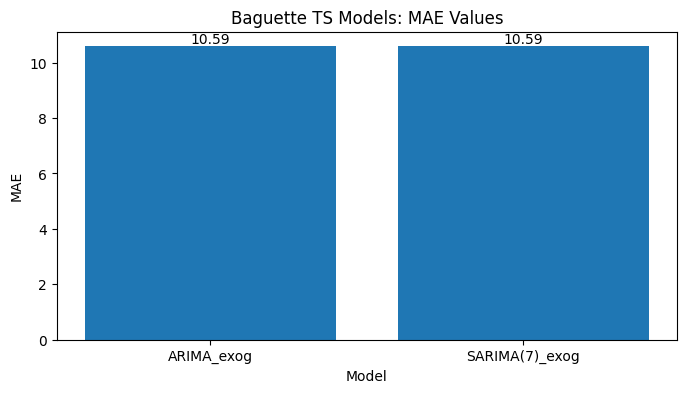

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Bag_MAE['Model'], Bag_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Baguette TS Models: MAE Values')

plt.show()

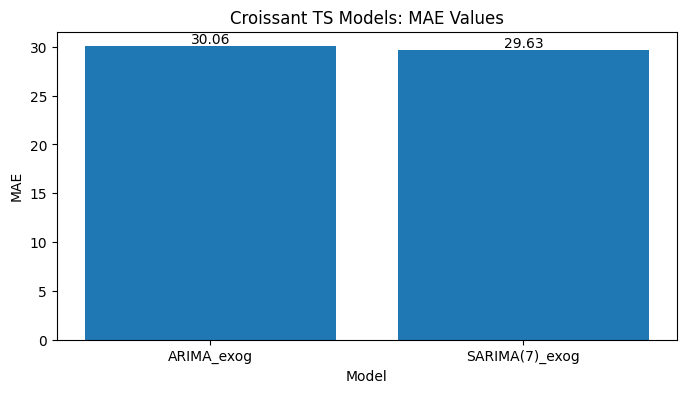

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Cro_MAE['Model'], Cro_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Croissant TS Models: MAE Values')

plt.show()

## All Models

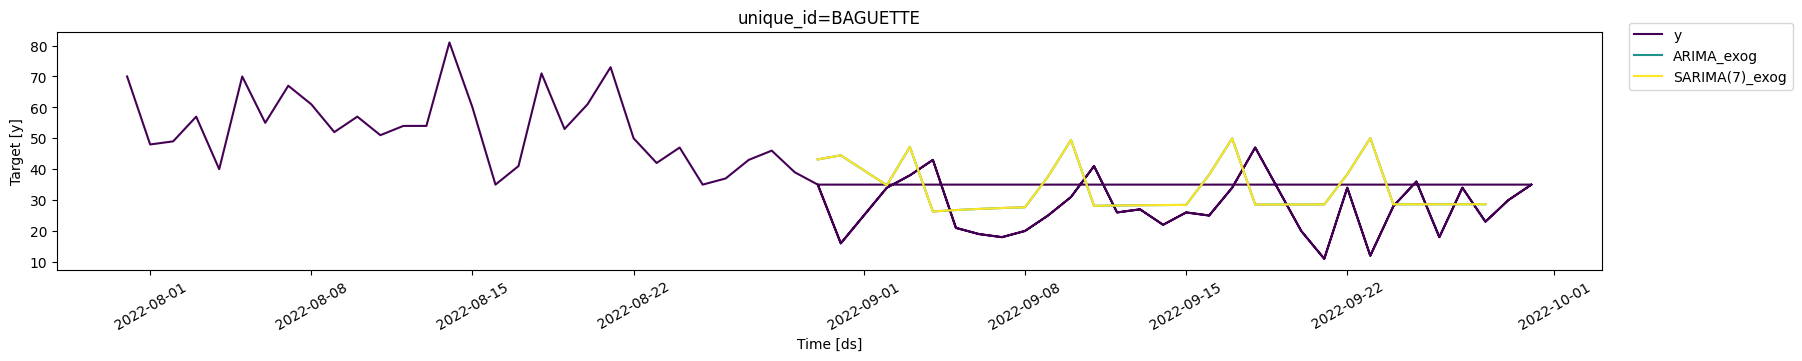

In [50]:
plot_series(
    df=df_simple,
    forecasts_df = eval_df,
    ids = ['BAGUETTE'],
    max_insample_length = 60,
    palette = 'viridis'
)

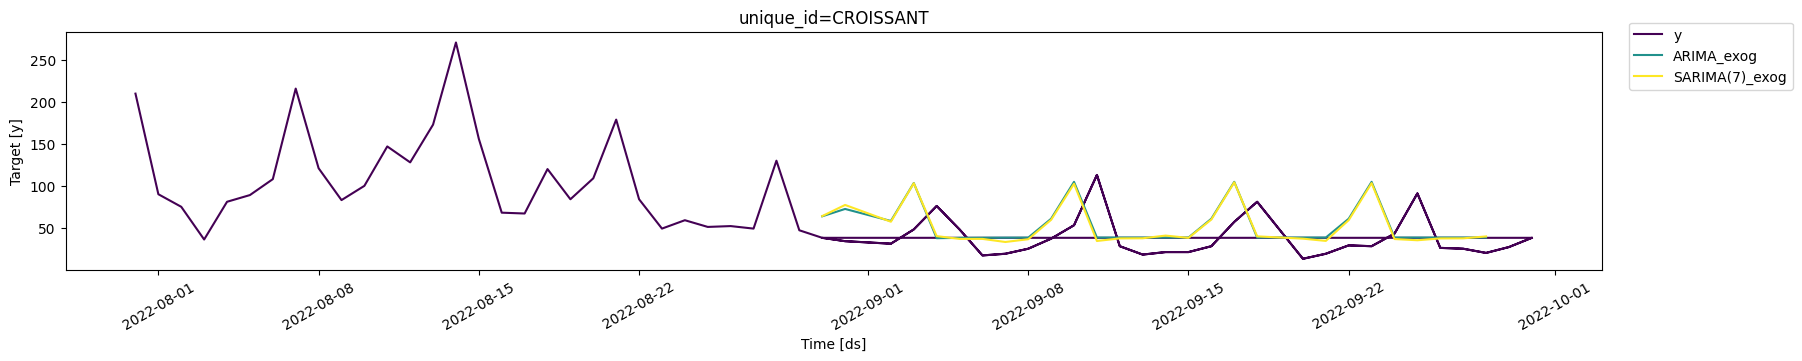

In [51]:
plot_series(
    df=df_simple,
    forecasts_df = eval_df,
    ids = ['CROISSANT'],
    max_insample_length = 60,
    palette = 'viridis'
)

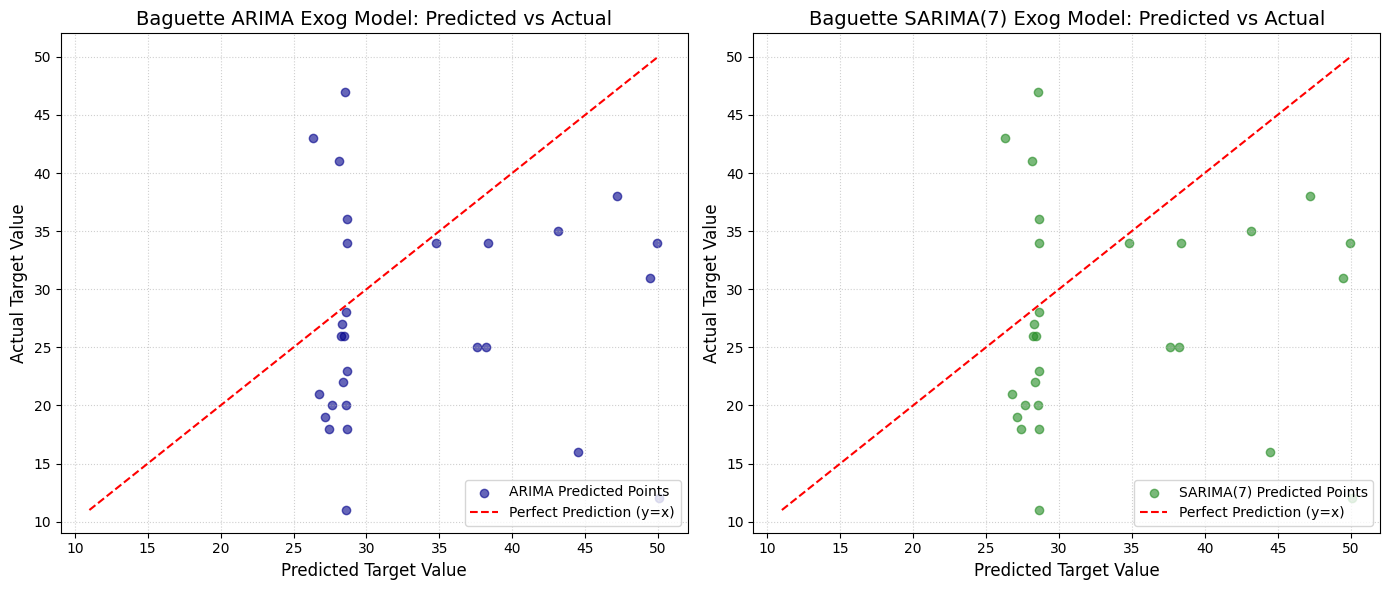

In [52]:
# Get data ready for plotting the two graphs

Bag_Actual = eval_df[eval_df['unique_id'] == 'BAGUETTE']['y']

Bag_pred_arima = eval_df[eval_df['unique_id'] == 'BAGUETTE']['ARIMA_exog']
Bag_pred_sarima7 = eval_df[eval_df['unique_id'] == 'BAGUETTE']['SARIMA(7)_exog']

######################################################################

# Create the figure with the three subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Bag_pred_arima, Bag_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Bag_pred_arima.min(), Bag_Actual.min())
max_val1 = max(Bag_pred_arima.max(), Bag_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Baguette ARIMA Exog Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Bag_pred_sarima7, Bag_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Bag_pred_sarima7.min(), Bag_Actual.min())
max_val2 = max(Bag_pred_sarima7.max(), Bag_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Baguette SARIMA(7) Exog Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

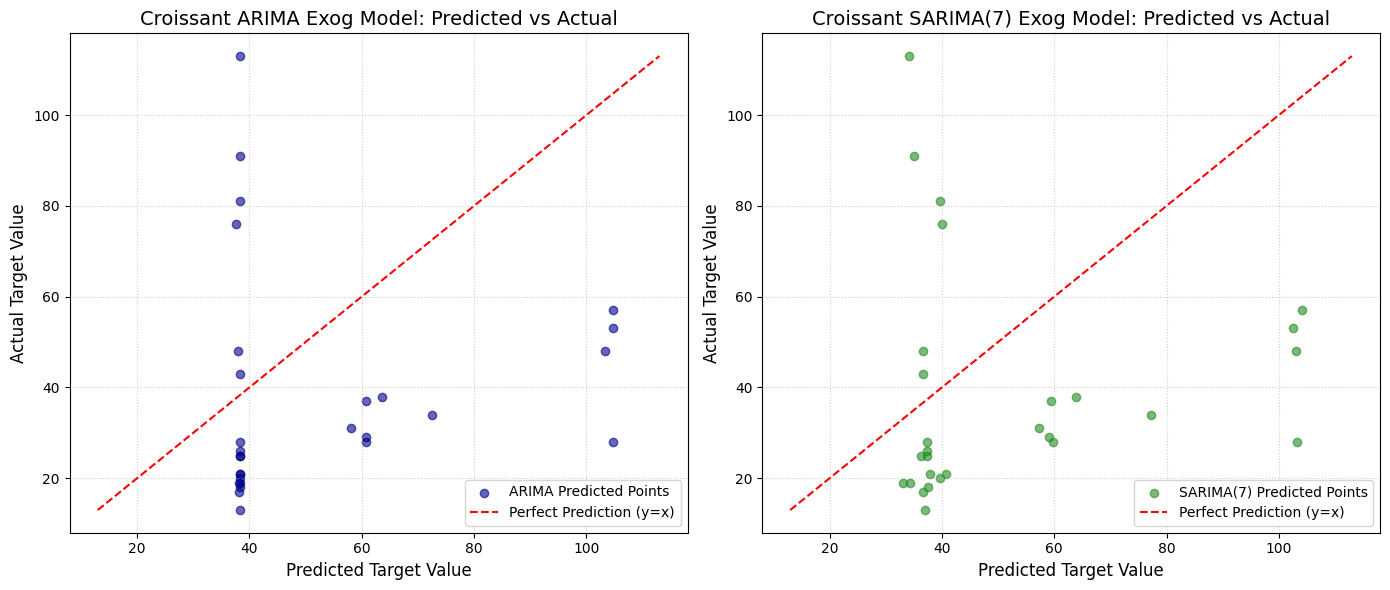

In [53]:
# Get data ready for plotting the two graphs

Cro_Actual = eval_df[eval_df['unique_id'] == 'CROISSANT']['y']

Cro_pred_arima = eval_df[eval_df['unique_id'] == 'CROISSANT']['ARIMA_exog']
Cro_pred_sarima7 = eval_df[eval_df['unique_id'] == 'CROISSANT']['SARIMA(7)_exog']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Cro_pred_arima, Cro_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Cro_pred_arima.min(), Cro_Actual.min())
max_val1 = max(Cro_pred_arima.max(), Cro_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Croissant ARIMA Exog Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Cro_pred_sarima7, Cro_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Cro_pred_sarima7.min(), Cro_Actual.min())
max_val2 = max(Cro_pred_sarima7.max(), Cro_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Croissant SARIMA(7) Exog Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

For both the baguette and croissant sales forecasts, the exogenous ARIMA model and the exogenous SARIMA(7) model yielded identical predictions. For baguette sales the addition of exogenous variables resulted in a slight but consistent improvement for both models, both exog models achieving an identical MAE of 10.59. For croissant sales the exogenous models both had MAE values of around $\sim 30$. Since the non-exogenous ARIMA (MAE 15.29) performed significantly better than the exogenous models, it seems that the chosen exogenous variables have just introduced noise in the forecasting of croissant sales. 

Note, the appearance of the predicted vs actual plots for the exog models have points clustered together in certain areas. This is because the predicted values are being determined by what is essentially a regression equation.

# Cross Validation: 30 Day Horizon, 3 Periods (90 Days)

## Non Exog Models

In [54]:
subset_unique_ids = ['BAGUETTE','CROISSANT']

subset_df_simple = df_simple[df_simple['unique_id'].isin(subset_unique_ids)].copy() 


horizon = 30

my_models = [

    AutoARIMA(seasonal = False, alias = 'ARIMA'),
    AutoARIMA(season_length = 7, alias = 'SARIMA(7)')
    
]

sf = StatsForecast(models = my_models, freq = 'D')

cv_df = sf.cross_validation(
    h=horizon,
    df=subset_df_simple,
    n_windows=3,                # For 3 months
    step_size=horizon,
    refit=True
)

cv_df.head()  

,unique_id,ds,cutoff,y,ARIMA,SARIMA(7)
0,BAGUETTE,2022-07-01,2022-06-30,39.0,32.159012,26.444192
1,BAGUETTE,2022-07-02,2022-06-30,42.0,35.556132,30.697219
2,BAGUETTE,2022-07-03,2022-06-30,74.0,34.083221,40.742543
3,BAGUETTE,2022-07-04,2022-06-30,46.0,30.972191,26.956726
4,BAGUETTE,2022-07-05,2022-06-30,29.0,26.098051,26.399185


In [55]:
eval_df = cv_df.drop(['cutoff'],axis=1)

In [56]:
evaluation = evaluate(eval_df, metrics = [mae])

evaluation.head()

,unique_id,metric,ARIMA,SARIMA(7)
0,BAGUETTE,mae,17.402551,18.882552
1,CROISSANT,mae,37.959852,38.442412


In [57]:
df_melted = pd.melt(evaluation, id_vars=['unique_id'], 
                    value_vars=['ARIMA','SARIMA(7)'],
                    var_name='Model',
                    value_name='MAE')

df_melted.head(10)

,unique_id,Model,MAE
0,BAGUETTE,ARIMA,17.402551
1,CROISSANT,ARIMA,37.959852
2,BAGUETTE,SARIMA(7),18.882552
3,CROISSANT,SARIMA(7),38.442412


In [58]:
# Making dataframes to use for Model MAE barplots

Bag_MAE = df_melted[df_melted['unique_id'] == 'BAGUETTE']
Cro_MAE = df_melted[df_melted['unique_id'] == 'CROISSANT']

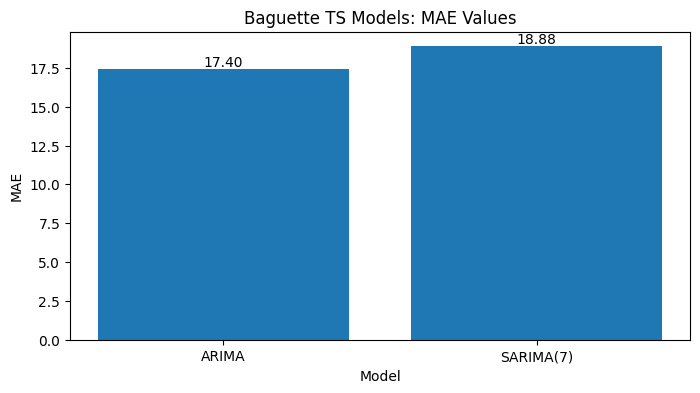

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Bag_MAE['Model'], Bag_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Baguette TS Models: MAE Values')

plt.show()

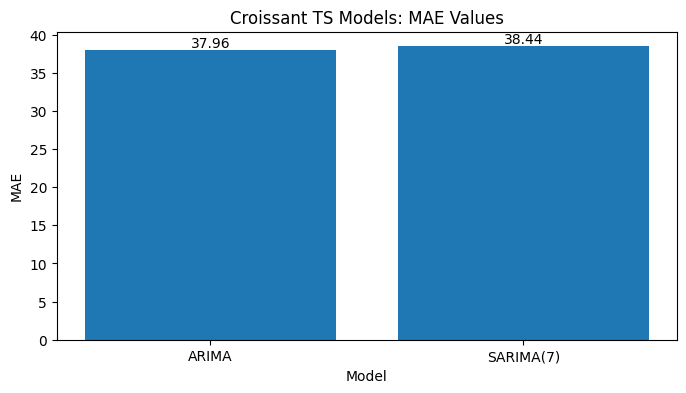

In [60]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Cro_MAE['Model'], Cro_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Croissant TS Models: MAE Values')

plt.show()

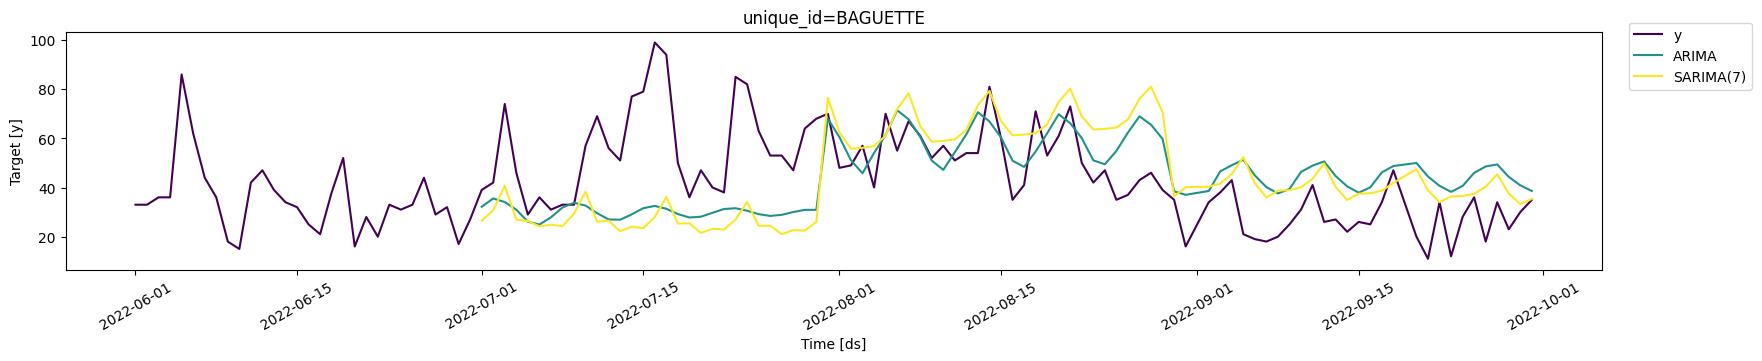

In [61]:
plot_series(
    df=subset_df_simple,
    forecasts_df=cv_df.drop(['y','cutoff'], axis=1),
    ids=['BAGUETTE'],
    max_insample_length=120,
    palette='viridis'
)

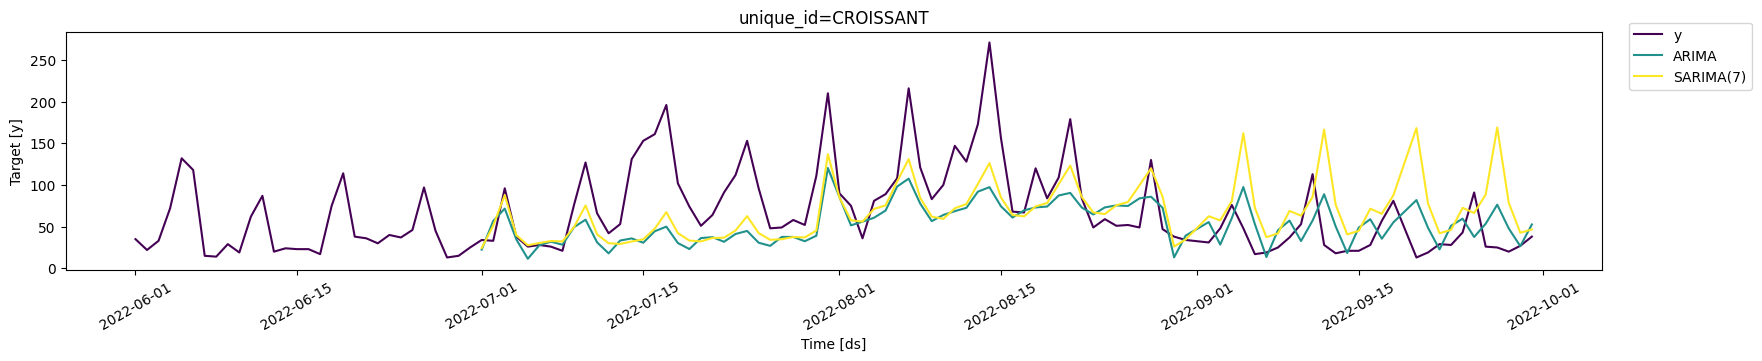

In [62]:
plot_series(
    df=subset_df_simple,
    forecasts_df=cv_df.drop(['y','cutoff'], axis=1),
    ids=['CROISSANT'],
    max_insample_length=120,
    palette='viridis'
)

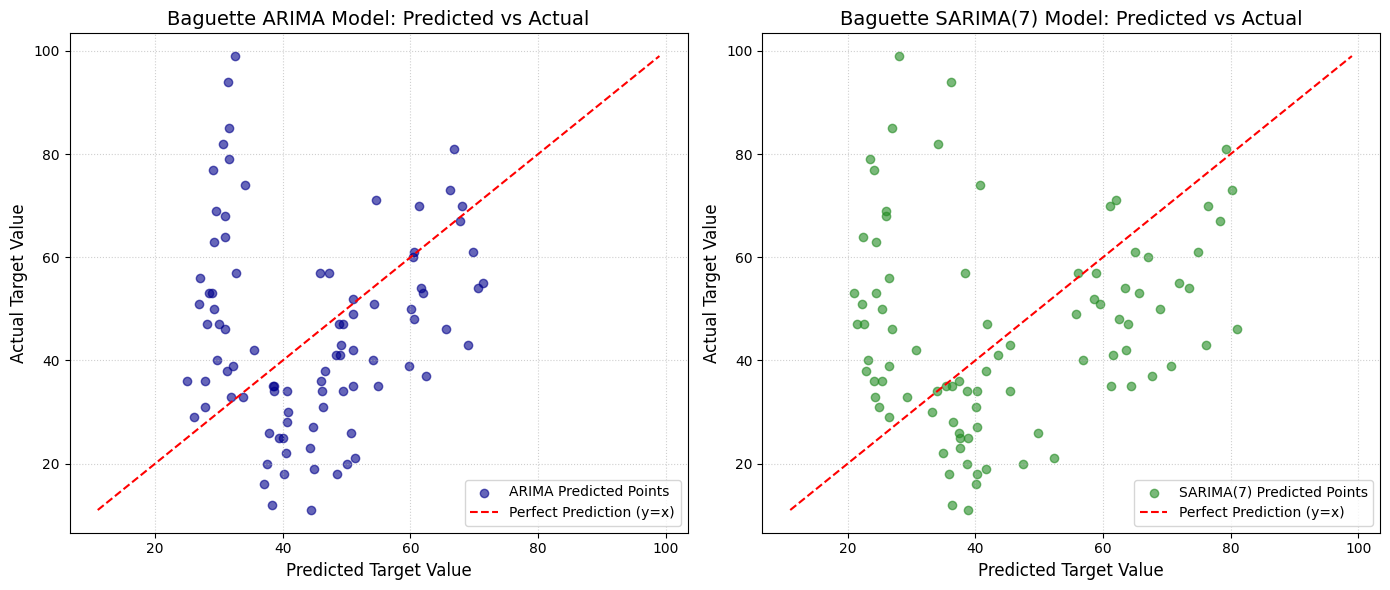

In [63]:
# Get data ready for plotting the two graphs

Bag_Actual = eval_df[eval_df['unique_id'] == 'BAGUETTE']['y']

Bag_pred_arima = eval_df[eval_df['unique_id'] == 'BAGUETTE']['ARIMA']
Bag_pred_sarima7 = eval_df[eval_df['unique_id'] == 'BAGUETTE']['SARIMA(7)']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Bag_pred_arima, Bag_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Bag_pred_arima.min(), Bag_Actual.min())
max_val1 = max(Bag_pred_arima.max(), Bag_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Baguette ARIMA Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Bag_pred_sarima7, Bag_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Bag_pred_sarima7.min(), Bag_Actual.min())
max_val2 = max(Bag_pred_sarima7.max(), Bag_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Baguette SARIMA(7) Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

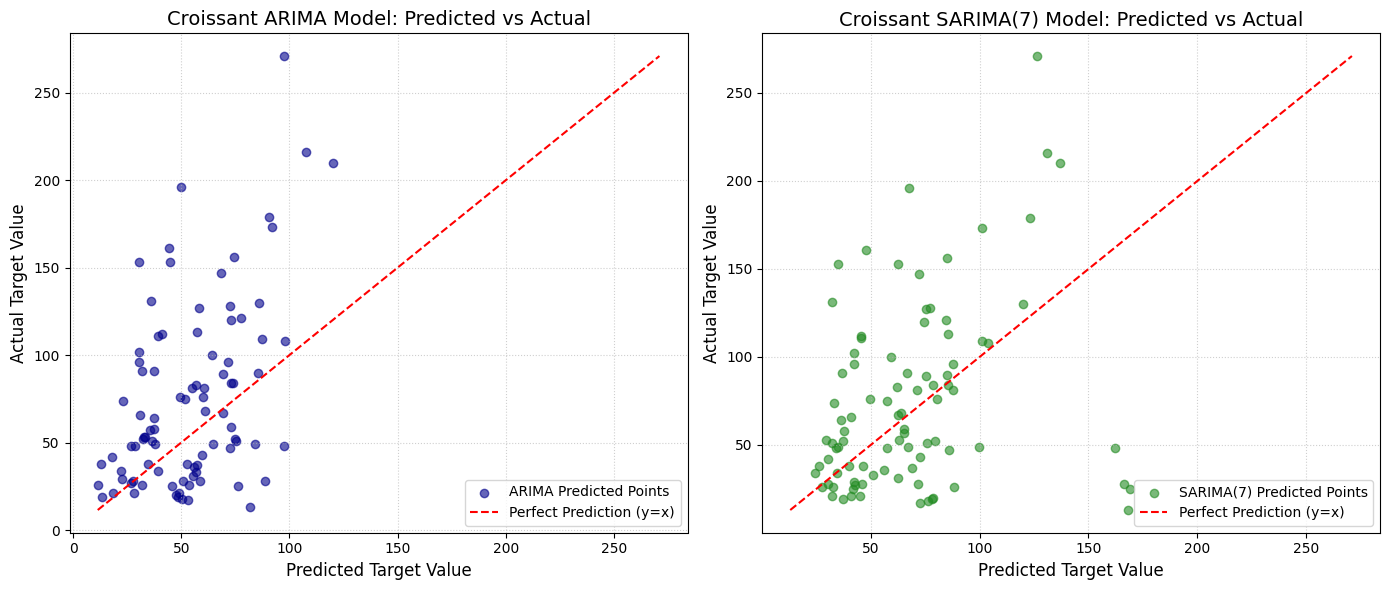

In [64]:
# Get data ready for plotting the two graphs

Cro_Actual = eval_df[eval_df['unique_id'] == 'CROISSANT']['y']

Cro_pred_arima = eval_df[eval_df['unique_id'] == 'CROISSANT']['ARIMA']
Cro_pred_sarima7 = eval_df[eval_df['unique_id'] == 'CROISSANT']['SARIMA(7)']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Cro_pred_arima, Cro_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Cro_pred_arima.min(), Cro_Actual.min())
max_val1 = max(Cro_pred_arima.max(), Cro_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Croissant ARIMA Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Cro_pred_sarima7, Cro_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Cro_pred_sarima7.min(), Cro_Actual.min())
max_val2 = max(Cro_pred_sarima7.max(), Cro_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Croissant SARIMA(7) Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

The cross validation method is far more reliable than the Train/Test split method because the models are tested multple times over. In this case there are three sequential 30 day forecasts that are recorded for model evaluation. With that said we see that for Baguette sales that the SARIMA(7) MAE scores changed notably between the Train/Test run and the cross validation run (Train/Test value: 12.74, CV value: 18.88). For baguette sales the ARIMA model did mariginally worse with cross validation, (Train/Test value: 16.48, CV value: 17.40). We see from these results that when using the larger 90 day cross validation forecast (30 days x window=3) that instead of the SARIMA(7) model performing better than the ARIMA model it actually performed a little worse. For croissant sales the SARIMA(7) model did slightly worse using cross validation (Train/Test value: 37.18, CV value: 38.44). The ARIMA model, for croissant sales, did much worse with cross validation (Train/Test value: 15.29, CV value: 37.96). Cross validation shows us that for croisssant sales that both of these models, ARIMA and SARIMA(7), are equally bad at forecasting.

## Exog Models

In [65]:
# Making additional exogenous variables (+ unit_price_euro) for dataframe
df_exog = df_full.copy()


# Rename the columns so they work with the StatsForecast library 
df_exog = df_exog.rename(columns={'date_only': 'ds',
                                  'article': 'unique_id',
                                  'Quantity': 'y'})

# Extract extra exogenous variables for prediction (Month, Day)
df_exog['Month'] = df_exog['ds'].dt.strftime('%B')
df_exog['DayOfWeek'] = df_exog['ds'].dt.strftime('%A')


# Classify all days that are not Saturday or Sunday as 'Weekday'
df_exog['DayOfWeek'] = np.where(
    df_exog['DayOfWeek'].isin(['Saturday', 'Sunday']),
    df_exog['DayOfWeek'], 'Weekday')


# Select the columns to be one-hot encoded
columns_to_encode = ['Month','DayOfWeek']


# Apply one-hot encoding
df_exog = pd.get_dummies(df_exog, columns=columns_to_encode, drop_first=True)


subset_unique_ids = ['BAGUETTE','CROISSANT']

subset_df_exog = df_exog[df_exog['unique_id'].isin(subset_unique_ids)].copy() 

In [66]:
# Making models to predict horizon of next 30 days

horizon = 30

my_models = [

    AutoARIMA(seasonal = False, alias = 'ARIMA_exog'),
    AutoARIMA(season_length = 7, alias = 'SARIMA(7)_exog'),
    
]

sf = StatsForecast(models = my_models, freq = 'D')

cv_exog_df = sf.cross_validation(
    h=horizon,
    df=subset_df_exog,
    n_windows=3,
    step_size=horizon,
    refit=True
)

cv_exog_df.head() 

,unique_id,ds,cutoff,y,ARIMA_exog,SARIMA(7)_exog
0,BAGUETTE,2022-07-01,2022-06-30,39.0,38.897114,38.931725
1,BAGUETTE,2022-07-02,2022-06-30,42.0,48.330116,47.740822
2,BAGUETTE,2022-07-03,2022-06-30,74.0,60.201611,59.571228
3,BAGUETTE,2022-07-04,2022-06-30,46.0,38.794010,38.842823
4,BAGUETTE,2022-07-05,2022-06-30,29.0,38.884804,39.086174


In [67]:
eval_df = cv_exog_df.drop(['cutoff'],axis=1)

In [68]:
evaluation = evaluate(eval_df, metrics = [mae])

evaluation.head()

,unique_id,metric,ARIMA_exog,SARIMA(7)_exog
0,BAGUETTE,mae,12.403060,12.405730
1,CROISSANT,mae,25.501778,25.221685


In [69]:
df_melted = pd.melt(evaluation, id_vars=['unique_id'], 
                    value_vars=['ARIMA_exog','SARIMA(7)_exog'],
                    var_name='Model',
                    value_name='MAE')

df_melted.head(10)

,unique_id,Model,MAE
0,BAGUETTE,ARIMA_exog,12.403060
1,CROISSANT,ARIMA_exog,25.501778
2,BAGUETTE,SARIMA(7)_exog,12.405730
3,CROISSANT,SARIMA(7)_exog,25.221685


In [70]:
# Making dataframes to use for Model MAE barplots

Bag_MAE = df_melted[df_melted['unique_id'] == 'BAGUETTE']
Cro_MAE = df_melted[df_melted['unique_id'] == 'CROISSANT']

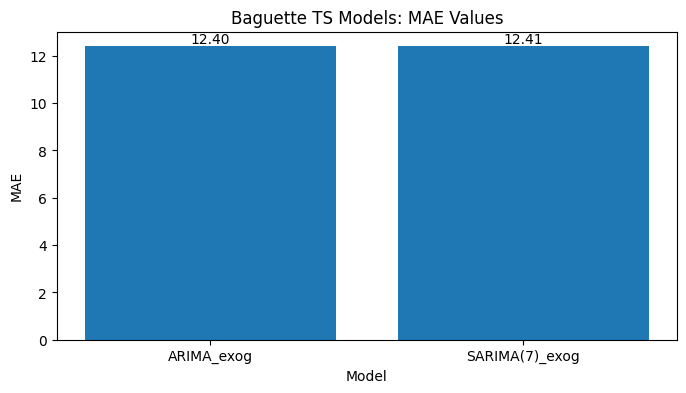

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Bag_MAE['Model'], Bag_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Baguette TS Models: MAE Values')

plt.show()

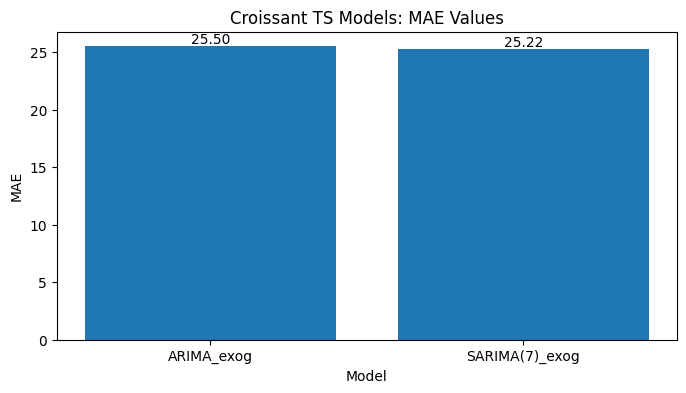

In [72]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(Cro_MAE['Model'], Cro_MAE['MAE'])

ax.bar_label(bars, fmt='{:,.2f}')

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Croissant TS Models: MAE Values')

plt.show()

In [73]:
plot_cv_exog_df = cv_exog_df[['ds','unique_id',
                              'ARIMA_exog','SARIMA(7)_exog']]

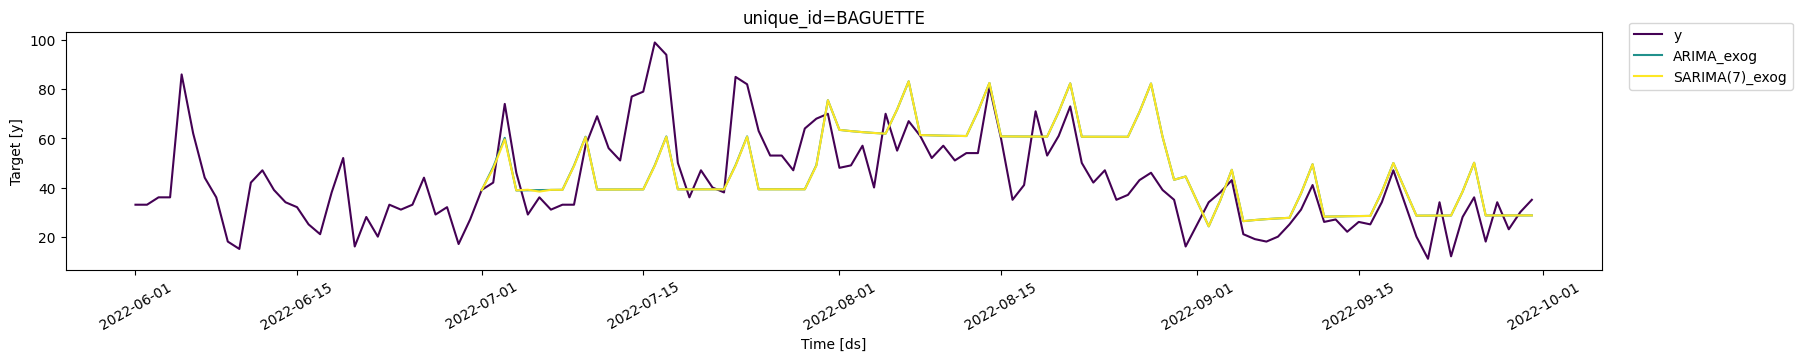

In [74]:
plot_series(
    df=df_simple, 
    forecasts_df = plot_cv_exog_df,
    ids = ['BAGUETTE'],
    max_insample_length = 120,
    palette = 'viridis'
)

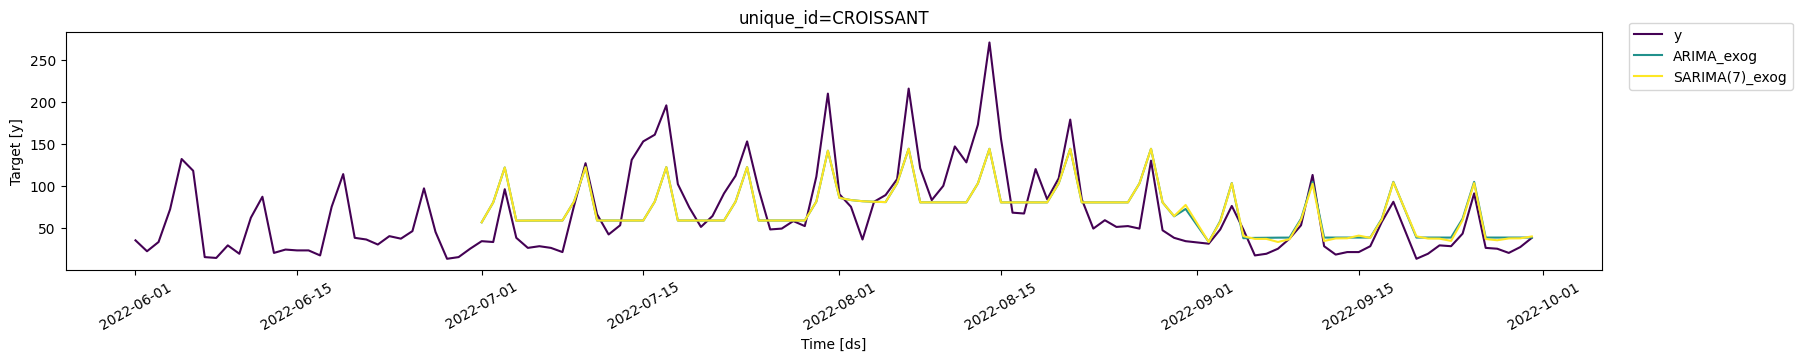

In [75]:
plot_series(
    df=df_simple, 
    forecasts_df = plot_cv_exog_df,
    ids = ['CROISSANT'],
    max_insample_length = 120,
    palette = 'viridis'
)

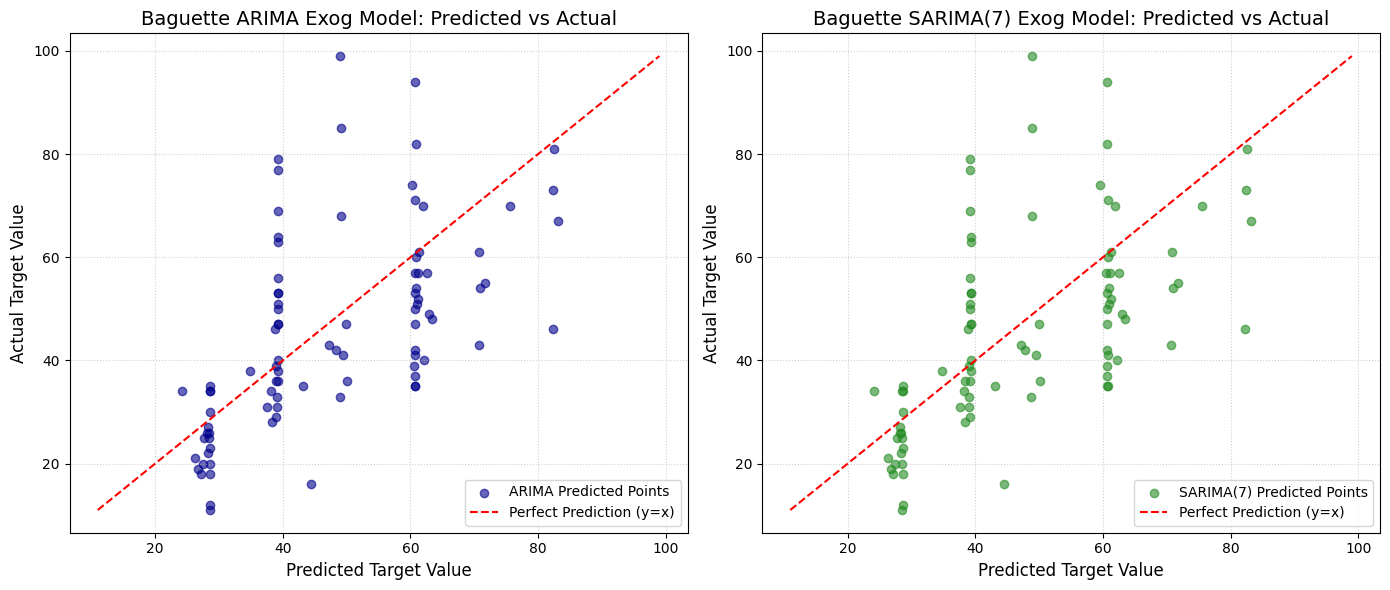

In [76]:
# Get data ready for plotting the two graphs

Bag_Actual = eval_df[eval_df['unique_id'] == 'BAGUETTE']['y']

Bag_pred_arima = eval_df[eval_df['unique_id'] == 'BAGUETTE']['ARIMA_exog']
Bag_pred_sarima7 = eval_df[eval_df['unique_id'] == 'BAGUETTE']['SARIMA(7)_exog']

######################################################################

# Create the figure with the three subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Bag_pred_arima, Bag_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Bag_pred_arima.min(), Bag_Actual.min())
max_val1 = max(Bag_pred_arima.max(), Bag_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Baguette ARIMA Exog Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Bag_pred_sarima7, Bag_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Bag_pred_sarima7.min(), Bag_Actual.min())
max_val2 = max(Bag_pred_sarima7.max(), Bag_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Baguette SARIMA(7) Exog Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

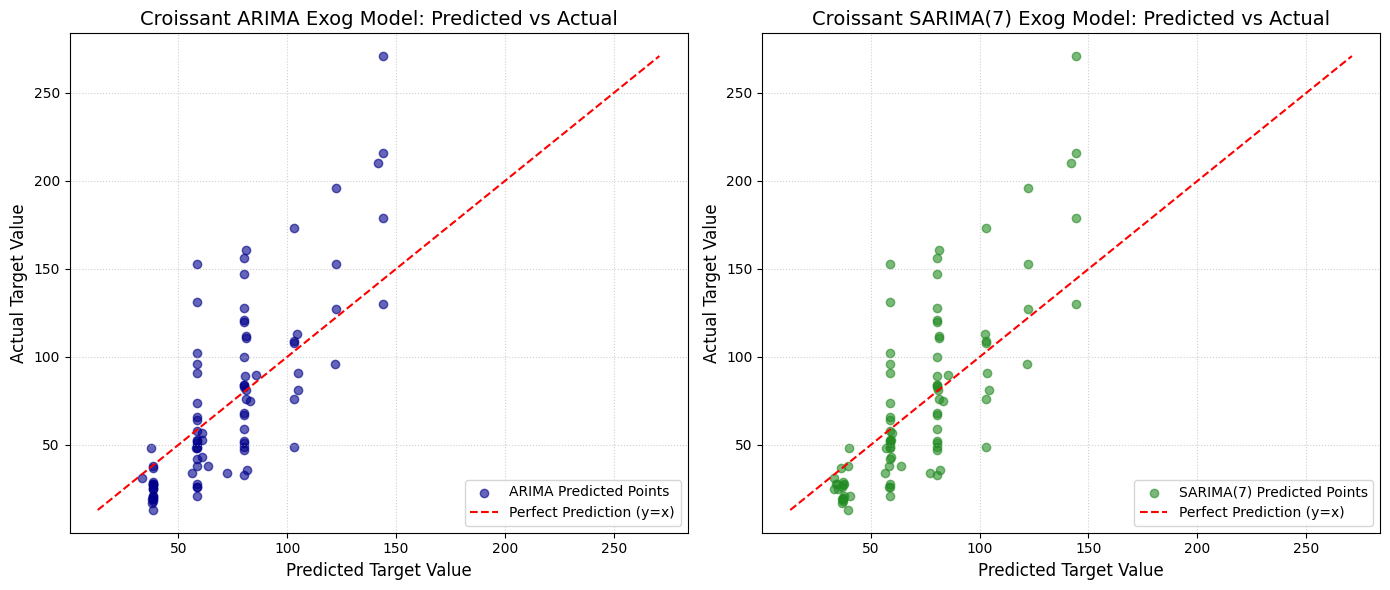

In [77]:
# Get data ready for plotting the two graphs

Cro_Actual = eval_df[eval_df['unique_id'] == 'CROISSANT']['y']

Cro_pred_arima = eval_df[eval_df['unique_id'] == 'CROISSANT']['ARIMA_exog']
Cro_pred_sarima7 = eval_df[eval_df['unique_id'] == 'CROISSANT']['SARIMA(7)_exog']

######################################################################

# Create the figure with the two subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

######################################################################

# Plot the first scatterplot on the first subplot

axes[0].scatter(Cro_pred_arima, Cro_Actual, color='darkblue',
                alpha=0.6, label='ARIMA Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val1 = min(Cro_pred_arima.min(), Cro_Actual.min())
max_val1 = max(Cro_pred_arima.max(), Cro_Actual.max())
line_range1 = np.linspace(min_val1, max_val1, 100)

axes[0].plot(line_range1, line_range1, color='red',
             linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[0].set_title('Croissant ARIMA Exog Model: Predicted vs Actual', fontsize=14)
axes[0].set_ylabel('Actual Target Value', fontsize=12)
axes[0].set_xlabel('Predicted Target Value', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

######################################################################

# Plot the second scatterplot on the second subplot

axes[1].scatter(Cro_pred_sarima7, Cro_Actual, color='forestgreen',
                 alpha=0.6, label='SARIMA(7) Predicted Points')


# Set up the plot so every point is shown and is evenly spaced

min_val2 = min(Cro_pred_sarima7.min(), Cro_Actual.min())
max_val2 = max(Cro_pred_sarima7.max(), Cro_Actual.max())
line_range2 = np.linspace(min_val2, max_val2, 100)

axes[1].plot(line_range2, line_range2, color='red',
              linestyle='--', label='Perfect Prediction (y=x)')


# Set all labels and set style

axes[1].set_title('Croissant SARIMA(7) Exog Model: Predicted vs Actual', fontsize=14)
axes[1].set_ylabel('Actual Target Value', fontsize=12)
axes[1].set_xlabel('Predicted Target Value', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc=4)

######################################################################

# Adjust layout to prevent overlapping titles/labels and show

plt.tight_layout()
plt.show()

Now to compare all the exogenous time series models performances with Train/Test split and cross validation. For baguette sales the ARIMA_exog model and SARIMA(7)_exog model did mariginally worse with cross validation, (Train/Test value: 10.59, CV value: ~12.40). For croissant sales the ARIMA_exog and SARIMA(7)_exog models did better with the longer cross validation run (Train/Test value: ~30, CV value: ~25)

Finally, to compare all of the cross validation trained models to each other (non-exogenous vs exogenous). For baguette sales the ARIMA model got an MAE of 17.40, and the SARIMA(7) model got an MAE score 18.88. The ARIMA_exog model had an MAE of 12.40 and the SARIMA(7)_exog model had an MAE of 12.41. For Croissant sales the ARIMA model had an MAE of 37.96 and the SARIMA(7) model had an MAE of 38.44. The ARIMA_exog model had an MAE of 25.50 and the SARIMA(7)_exog model had an MAE of 25.22.

Therefore the best model to predict baguette sales is the ARIMA_exog model (MAE 12.40) and the best model to predict croissant sales is the SARIMA(7)_exog model (MAE 25.22).